# Thermal Hotspt_Detection

## 01. Project Definition

Input:
- Colored/pseudo-color thermal solar-panel images
- YOLO-compatible bounding-box annotations

Output:
- Hotspot class
- Bounding box
- Confidence score

In [1]:
from pathlib import Path
import yaml


# Dataset Collection

In [2]:
DATABASE_DIR = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Database/colored_thermal_pannel_db"
)

TRAIN_DIR = DATABASE_DIR / "train"
VALID_DIR = DATABASE_DIR / "valid"
TEST_DIR = DATABASE_DIR / "test"

TRAIN_IMAGES = TRAIN_DIR / "images"
VALID_IMAGES = VALID_DIR / "images"
TEST_IMAGES = TEST_DIR / "images"

TRAIN_LABELS = TRAIN_DIR / "labels"
VALID_LABELS = VALID_DIR / "labels"
TEST_LABELS = TEST_DIR / "labels"

SOURCE_DATA_YAML = DATABASE_DIR / "data.yaml"


In [3]:
PREPARED_DATASET_DIR = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset"
)
DATA_YAML = PREPARED_DATASET_DIR / "data.yaml"

with open(SOURCE_DATA_YAML, "r") as file:
    source_data = yaml.safe_load(file)

SOURCE_CLASS_NAMES = source_data["names"]
if isinstance(SOURCE_CLASS_NAMES, dict):
    SOURCE_CLASS_NAMES = [
        SOURCE_CLASS_NAMES[k]
        for k in sorted(SOURCE_CLASS_NAMES, key=lambda x: int(x))
    ]
SOURCE_CLASS_NAMES = [str(x) for x in SOURCE_CLASS_NAMES]

TARGET_CLASS_NAME = "fault"

if TARGET_CLASS_NAME not in SOURCE_CLASS_NAMES:
    raise ValueError(
        f"Target class '{TARGET_CLASS_NAME}' not found. "
        f"Available classes: {SOURCE_CLASS_NAMES}"
    )

TARGET_CLASS_ID = SOURCE_CLASS_NAMES.index(TARGET_CLASS_NAME)

CLASS_NAMES = ["hotspot"]

print("Dataset:", DATABASE_DIR)
print("Source YAML:", SOURCE_DATA_YAML)
print("Prepared dataset:", PREPARED_DATASET_DIR)
print("Source classes:", SOURCE_CLASS_NAMES)
print("Target class:", TARGET_CLASS_ID, TARGET_CLASS_NAME)

Dataset: /home/hraj/Workspace/Solor_defect_DB/Database/colored_thermal_pannel_db
Source YAML: /home/hraj/Workspace/Solor_defect_DB/Database/colored_thermal_pannel_db/data.yaml
Prepared dataset: /home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset
Source classes: ['0', '1', '2', 'fault']
Target class: 3 fault


# Dataset Analysis

In [4]:
from collections import Counter, defaultdict
import hashlib
import pandas as pd

In [5]:
def count_files(directory, suffix=None):
    if not directory.exists():
        return 0
    files = [p for p in directory.rglob("*") if p.is_file()]
    if suffix:
        files = [p for p in files if p.suffix.lower() == suffix.lower()]
    return len(files)

for name, image_dir, label_dir in [
    ("train", TRAIN_IMAGES, TRAIN_LABELS),
    ("valid", VALID_IMAGES, VALID_LABELS),
    ("test", TEST_IMAGES, TEST_LABELS),
]:
    print(
        f"{name:>5} | images: {count_files(image_dir):4d} | "
        f"labels: {count_files(label_dir, '.txt'):4d}"
    )

print("Total images:",
      sum(count_files(d) for d in [TRAIN_IMAGES, VALID_IMAGES, TEST_IMAGES]))
print("Total labels:",
      sum(count_files(d, ".txt") for d in [TRAIN_LABELS, VALID_LABELS, TEST_LABELS]))

image_shapes = []
mode_counts = Counter()

for image_path in TRAIN_IMAGES.iterdir():
    if image_path.is_file():
        try:
            with Image.open(image_path) as image:
                image_shapes.append(image.size)
                mode_counts[image.mode] += 1
        except Exception:
            pass

print("\nTraining image shapes:")
for shape, count in Counter(image_shapes).most_common():
    print(f"{shape}: {count}")

print("\nTraining image modes:")
for mode, count in mode_counts.items():
    print(f"{mode}: {count}")


train | images: 11034 | labels: 11034
valid | images:  339 | labels:  339
 test | images:  235 | labels:  235
Total images: 11608
Total labels: 11608

Training image shapes:

Training image modes:


In [6]:
print("Number of classes:", source_data["nc"])
print("Class names:")
for index, name in enumerate(SOURCE_CLASS_NAMES):
    print(f"{index}: {name}")


Number of classes: 4
Class names:
0: 0
1: 1
2: 2
3: fault


In [7]:
def annotation_statistics(label_dir):
    class_counter = Counter()
    image_class_counter = Counter()
    bbox_widths, bbox_heights, bbox_areas = [], [], []
    format_counts = Counter()
    empty_files, invalid_files = [], []

    for label_path in label_dir.glob("*.txt"):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]

        if not lines:
            empty_files.append(label_path.name)
            continue

        classes_in_image = set()

        for line in lines:
            values = line.split()
            format_counts[len(values)] += 1

            try:
                class_id = int(values[0])
                if len(values) == 5:
                    xc, yc, w, h = map(float, values[1:])
                    class_counter[class_id] += 1
                    bbox_widths.append(w)
                    bbox_heights.append(h)
                    bbox_areas.append(w * h)
                    classes_in_image.add(class_id)
                elif len(values) > 5 and len(values[1:]) % 2 == 0:
                    class_counter[class_id] += 1
                    classes_in_image.add(class_id)
                else:
                    invalid_files.append(label_path.name)
            except Exception:
                invalid_files.append(label_path.name)

        for class_id in classes_in_image:
            image_class_counter[class_id] += 1

    return (
        class_counter, image_class_counter, bbox_widths, bbox_heights,
        bbox_areas, format_counts, empty_files, invalid_files
    )

(
    class_counts, image_class_counts, bbox_widths, bbox_heights,
    bbox_areas, format_counts, empty_labels, invalid_labels
) = annotation_statistics(TRAIN_LABELS)

rows = []
for class_id, name in enumerate(SOURCE_CLASS_NAMES):
    rows.append({
        "class_id": class_id,
        "class_name": name,
        "annotations": class_counts[class_id],
        "images_containing_class": image_class_counts[class_id],
    })

class_distribution = pd.DataFrame(rows)
display(class_distribution)

print("\nAnnotation line formats:", dict(sorted(format_counts.items())))
print("Empty training label files:", len(empty_labels))
print("Invalid training label files:", len(invalid_labels))


,class_id,class_name,annotations,images_containing_class
0,0,0,273,66
1,1,1,213,57
2,2,2,66,24
3,3,fault,30045,10962



Annotation line formats: {5: 30372, 11: 88, 13: 61, 15: 66, 17: 10}
Empty training label files: 3
Invalid training label files: 0


Annotation Verification

In [8]:
def validate_annotations(label_dir, class_names):
    issues = []

    for label_path in label_dir.glob("*.txt"):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]

        for line_no, line in enumerate(lines, start=1):
            values = line.split()

            try:
                class_id = int(values[0])
            except Exception:
                issues.append((label_path.name, line_no, "invalid_class_id"))
                continue

            if not 0 <= class_id < len(class_names):
                issues.append((label_path.name, line_no, "class_id_out_of_range"))
                continue

            if len(values) == 5:
                try:
                    coords = list(map(float, values[1:]))
                    if not all(0 <= v <= 1 for v in coords):
                        issues.append((label_path.name, line_no, "bbox_out_of_range"))
                    if coords[2] <= 0 or coords[3] <= 0:
                        issues.append((label_path.name, line_no, "zero_or_negative_bbox"))
                except Exception:
                    issues.append((label_path.name, line_no, "invalid_bbox"))
            elif len(values) > 5:
                if len(values[1:]) % 2 != 0:
                    issues.append((label_path.name, line_no, "invalid_polygon"))
            else:
                issues.append((label_path.name, line_no, "unsupported_annotation_format"))

    return pd.DataFrame(issues, columns=["file", "line", "issue"])

annotation_issues = validate_annotations(TRAIN_LABELS, SOURCE_CLASS_NAMES)

if len(annotation_issues):
    display(annotation_issues["issue"].value_counts().rename_axis("issue").reset_index(name="count"))
    display(annotation_issues.head(30))
else:
    print("No structural annotation issues found in training labels.")

print("\nSample original annotations:")
shown = 0
for label_path in TRAIN_LABELS.glob("*.txt"):
    lines = [x.strip() for x in label_path.read_text().splitlines() if x.strip()]
    if lines:
        print(label_path.name)
        for line in lines[:5]:
            print(" ", len(line.split()), "values:", line[:160])
        shown += 1
    if shown >= 10:
        break


No structural annotation issues found in training labels.

Sample original annotations:
FLIR1305_jpg.rf.d71bbb55653920aee24b59f3b4c96f24.txt
  5 values: 3 0.6416666666666667 0.709375 0.153125 0.5322916666666667
  5 values: 3 0.44895833333333335 0.03125 0.051041666666666666 0.029166666666666667
imgFC10_png.rf.ec57de0ae298549f21d080d6246f215e.txt
  5 values: 3 0.46770833333333334 0.7885416666666667 0.03854166666666667 0.035416666666666666
FLIR1392_jpg.rf.2e6013fb75a88f1cb8f463019129dde2.txt
  5 values: 3 0.45625 0.058333333333333334 0.05416666666666667 0.0375
  5 values: 3 0.575 0.6635416666666667 0.22395833333333334 0.14739583333333334
FLIR1406_jpg.rf.03360d74d692a41991db80ea680b32fc.txt
  5 values: 3 0.24166666666666667 0.8854166666666666 0.07604166666666666 0.0953125
150_jpg.rf.f15b25dd503720094ba67a1b6dc05927.txt
  5 values: 3 0.2708333333333333 0.6770833333333334 0.05 0.040625
  5 values: 3 0.43854166666666666 0.7104166666666667 0.05520833333333333 0.057291666666666664
  5 values: 3

Missing / Data check

In [9]:
def image_hash(image_path):
    hasher = hashlib.md5()
    with open(image_path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def build_hash_map(image_dir):
    hashes = defaultdict(list)
    for image_path in image_dir.iterdir():
        if image_path.is_file():
            try:
                hashes[image_hash(image_path)].append(image_path.name)
            except Exception:
                pass
    return hashes

train_hashes = build_hash_map(TRAIN_IMAGES)
valid_hashes = build_hash_map(VALID_IMAGES)
test_hashes = build_hash_map(TEST_IMAGES)

train_valid = set(train_hashes) & set(valid_hashes)
train_test = set(train_hashes) & set(test_hashes)
valid_test = set(valid_hashes) & set(test_hashes)

print("Train ↔ Valid duplicate groups:", len(train_valid))
print("Train ↔ Test duplicate groups :", len(train_test))
print("Valid ↔ Test duplicate groups :", len(valid_test))


Train ↔ Valid duplicate groups: 11
Train ↔ Test duplicate groups : 22
Valid ↔ Test duplicate groups : 0


# Data Preperation

In [11]:
import shutil

In [12]:
def polygon_to_bbox(values):
    coordinates = [float(v) for v in values[1:]]
    x_values = coordinates[0::2]
    y_values = coordinates[1::2]

    x_min, x_max = min(x_values), max(x_values)
    y_min, y_max = min(y_values), max(y_values)

    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    width = x_max - x_min
    height = y_max - y_min

    return f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

def prepare_label_file(source_label, destination_label):
    prepared = []

    if source_label.exists():
        lines = [x.strip() for x in source_label.read_text().splitlines() if x.strip()]

        for line in lines:
            values = line.split()

            try:
                class_id = int(values[0])
            except Exception:
                continue

            if class_id != TARGET_CLASS_ID:
                continue

            if len(values) == 5:
                try:
                    coords = [float(v) for v in values[1:]]
                    if all(0 <= v <= 1 for v in coords) and coords[2] > 0 and coords[3] > 0:
                        prepared.append(
                            "0 " + " ".join(f"{v:.6f}" for v in coords)
                        )
                except Exception:
                    pass

            elif len(values) > 5 and len(values[1:]) % 2 == 0:
                prepared.append(polygon_to_bbox(values))

    destination_label.parent.mkdir(parents=True, exist_ok=True)
    destination_label.write_text("\n".join(prepared))

def prepare_split(source_image_dir, source_label_dir, destination_split):
    destination_images = destination_split / "images"
    destination_labels = destination_split / "labels"

    destination_images.mkdir(parents=True, exist_ok=True)
    destination_labels.mkdir(parents=True, exist_ok=True)

    for image_path in source_image_dir.iterdir():
        if not image_path.is_file():
            continue

        shutil.copy2(image_path, destination_images / image_path.name)

        source_label = source_label_dir / image_path.with_suffix(".txt").name
        destination_label = destination_labels / image_path.with_suffix(".txt").name

        prepare_label_file(source_label, destination_label)

if PREPARED_DATASET_DIR.exists():
    shutil.rmtree(PREPARED_DATASET_DIR)

prepare_split(TRAIN_IMAGES, TRAIN_LABELS, PREPARED_DATASET_DIR / "train")
prepare_split(VALID_IMAGES, VALID_LABELS, PREPARED_DATASET_DIR / "valid")
prepare_split(TEST_IMAGES, TEST_LABELS, PREPARED_DATASET_DIR / "test")

print("Prepared dataset created:", PREPARED_DATASET_DIR)


Prepared dataset created: /home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset


In [13]:
def validate_prepared_dataset(dataset_dir):
    rows = []

    for split in ["train", "valid", "test"]:
        image_dir = dataset_dir / split / "images"
        label_dir = dataset_dir / split / "labels"

        images = [p for p in image_dir.iterdir() if p.is_file()]
        labels = list(label_dir.glob("*.txt"))

        hotspot_annotations = 0
        images_with_hotspot = 0
        invalid_lines = 0

        for label_path in labels:
            lines = [x.strip() for x in label_path.read_text().splitlines() if x.strip()]
            has_hotspot = False

            for line in lines:
                values = line.split()

                if len(values) != 5 or values[0] != "0":
                    invalid_lines += 1
                    continue

                try:
                    coords = [float(v) for v in values[1:]]
                    if not all(0 <= v <= 1 for v in coords) or coords[2] <= 0 or coords[3] <= 0:
                        invalid_lines += 1
                        continue
                except Exception:
                    invalid_lines += 1
                    continue

                hotspot_annotations += 1
                has_hotspot = True

            images_with_hotspot += int(has_hotspot)

        rows.append({
            "split": split,
            "images": len(images),
            "labels": len(labels),
            "images_with_hotspot": images_with_hotspot,
            "negative_images": len(images) - images_with_hotspot,
            "hotspot_annotations": hotspot_annotations,
            "invalid_lines": invalid_lines,
        })

    return pd.DataFrame(rows)

prepared_stats = validate_prepared_dataset(PREPARED_DATASET_DIR)
display(prepared_stats)


,split,images,labels,images_with_hotspot,negative_images,hotspot_annotations,invalid_lines
0,train,11034,11034,10962,72,30045,0
1,valid,339,339,335,4,572,0
2,test,235,235,232,3,489,0


# Model Training

In [17]:
from ultralytics.data.utils import check_det_dataset
from ultralytics import YOLO

In [16]:
data = {
    "path": str(PREPARED_DATASET_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": CLASS_NAMES,
}

with open(DATA_YAML, "w") as file:
    yaml.safe_dump(data, file, sort_keys=False)

print(DATA_YAML)
print(check_det_dataset(str(DATA_YAML)))


/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/data.yaml
{'path': PosixPath('/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset'), 'train': '/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/train/images', 'val': '/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/valid/images', 'test': '/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/test/images', 'nc': 1, 'names': {0: 'hotspot'}, 'yaml_file': '/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/data.yaml', 'channels': 3}


In [ ]:
MODEL_NAME = "yolo26m.pt"
model = YOLO(MODEL_NAME)


Model loaded: yolo26m.pt


In [19]:
IMG_SIZE = 640
BATCH_SIZE = 4
EPOCHS = 50
WORKERS = 2
DEVICE = "cpu"

AUGMENTATION = {
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.10,
    "degrees": 5.0,
    "translate": 0.05,
    "scale": 0.20,
    "fliplr": 0.5,
    "flipud": 0.0,
    "mosaic": 0.5,
    "mixup": 0.0,
}

PROJECT_DIR = (
    Path.home()
    / "Workspace"
    / "Solor_defect_DB"
    / "Solar_Inspection"
    / "Experiment"
    / "runs"
    / "thermal_hotspot_detection"
)

RUN_NAME = "baseline"

print("Epochs:", EPOCHS)
print("Image size:", IMG_SIZE)
print("Batch:", BATCH_SIZE)
print("Device:", DEVICE)


Epochs: 50
Image size: 640
Batch: 4
Device: cpu


In [ ]:
result = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    workers=WORKERS,
    device=DEVICE,

    hsv_h=AUGMENTATION["hsv_h"],
    hsv_s=AUGMENTATION["hsv_s"],
    hsv_v=AUGMENTATION["hsv_v"],
    degrees=AUGMENTATION["degrees"],
    translate=AUGMENTATION["translate"],
    scale=AUGMENTATION["scale"],
    fliplr=AUGMENTATION["fliplr"],
    flipud=AUGMENTATION["flipud"],
    mosaic=AUGMENTATION["mosaic"],
    mixup=AUGMENTATION["mixup"],

    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

print("Thermal hotspot baseline training completed.")


New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.152 🚀 Python-3.10.12 torch-2.14.0+cu130 CPU (13th Gen Intel Core i5-13420H)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.

/home/hraj/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Using 11034 train, 339 val images for fraction=1.0 at imgsz=640
Using 0 dataloader workers
Logging results to /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       1/50         0G      1.729      2.135   0.008071          9        640: 100% ━━━━━━━━━━━━ 2759/2759 6.0s/it 4:36:414.5ss05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 3.9s/it 2:484.0ss
                   all        339        572      0.604      0.561      0.518      0.216

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       2/50         0G      1.761      1.374   0.008564          3        640: 100% ━━━━━━━━━━━━ 2759/2759 5.7s/it 4:23:604.5ss08
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/

# Training Analysis

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [17]:
PROJECT_DIR = Path.home() / "Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection"
RUN_NAME = "baseline"

PREPARED_DATASET_DIR = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset"
)
DATA_YAML = PREPARED_DATASET_DIR / "data.yaml"

In [9]:
candidate_runs = sorted(
    PROJECT_DIR.glob(f"{RUN_NAME}*"),
    key=lambda p: p.stat().st_mtime
)

if not candidate_runs:
    raise FileNotFoundError(f"No training run found under {PROJECT_DIR}")
RUN_DIR = candidate_runs[-1]

RESULTS_CSV = RUN_DIR / "results.csv"
RESULTS_PLOT = RUN_DIR / "results.png"
BEST_MODEL = RUN_DIR / "weights" / "best.pt"

print("Run directory:", RUN_DIR)
print("Best model:", BEST_MODEL)
print("Exists:", BEST_MODEL.exists())

if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV)
    results_df.columns = [c.strip() for c in results_df.columns]
    display(results_df.tail())


Run directory: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline
Best model: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.pt
Exists: True


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
7,8,130171.0,1.47458,0.93377,0.00661,0.71499,0.67832,0.69266,0.32773,1.70567,1.24250,0.00675,0.001723,0.001723,0.001723
8,9,146270.0,1.45557,0.90664,0.00651,0.77445,0.68357,0.70390,0.32855,1.70337,1.24512,0.00663,0.001683,0.001683,0.001683
9,10,162320.0,1.43766,0.89211,0.00643,0.74675,0.69056,0.72118,0.36124,1.69302,1.13542,0.00659,0.001644,0.001644,0.001644
10,11,179129.0,1.40877,0.85901,0.00624,0.77490,0.71014,0.75763,0.36873,1.66122,1.07840,0.00644,0.001604,0.001604,0.001604
11,12,194807.0,1.39300,0.85422,0.00614,0.73518,0.73285,0.71648,0.35178,1.68351,1.07376,0.00668,0.001564,0.001564,0.001564


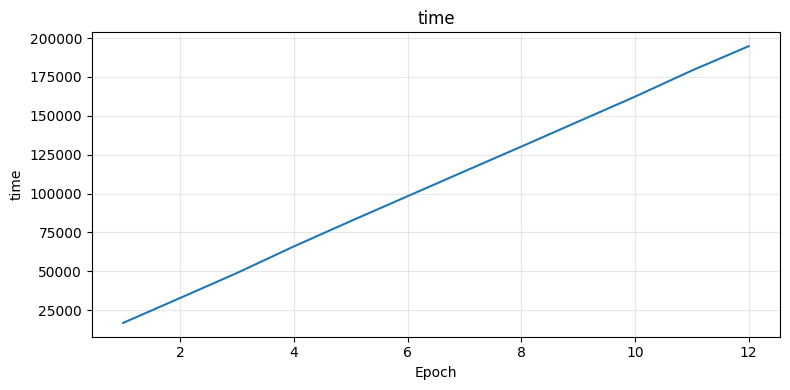

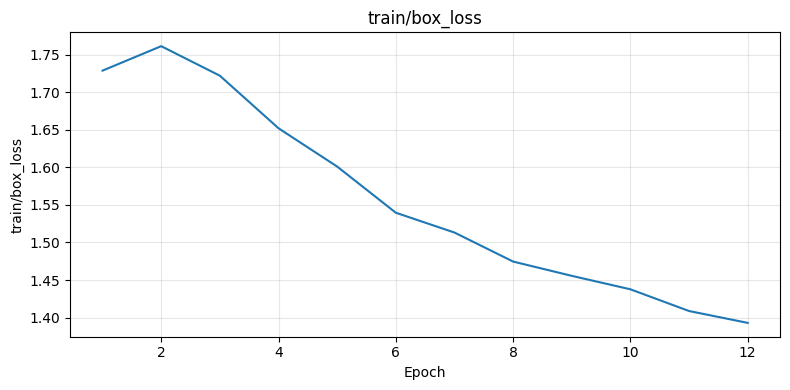

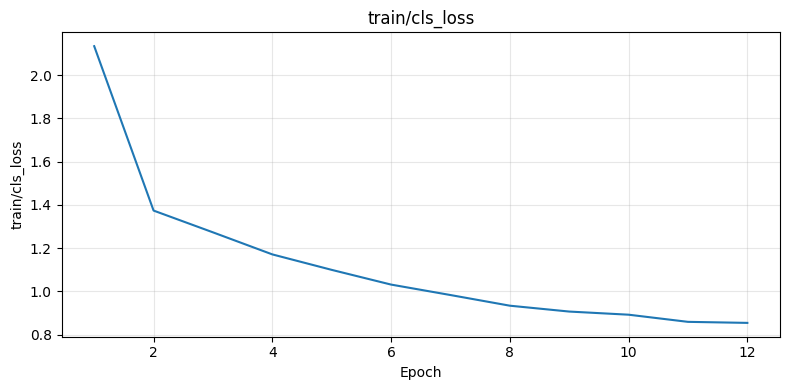

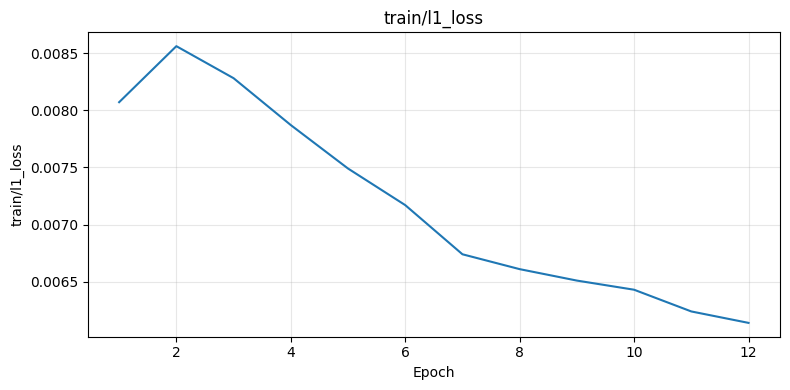

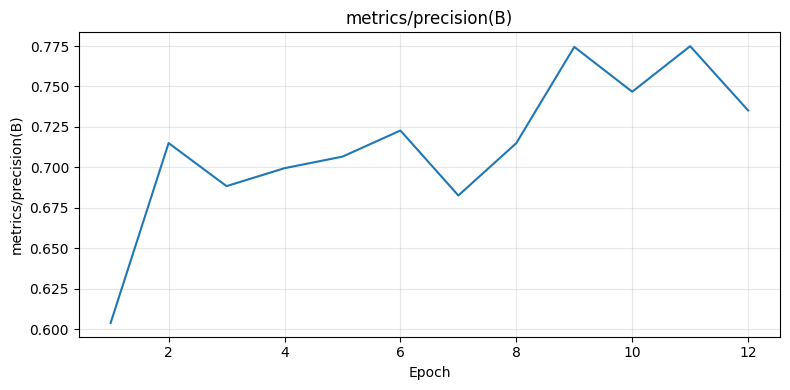

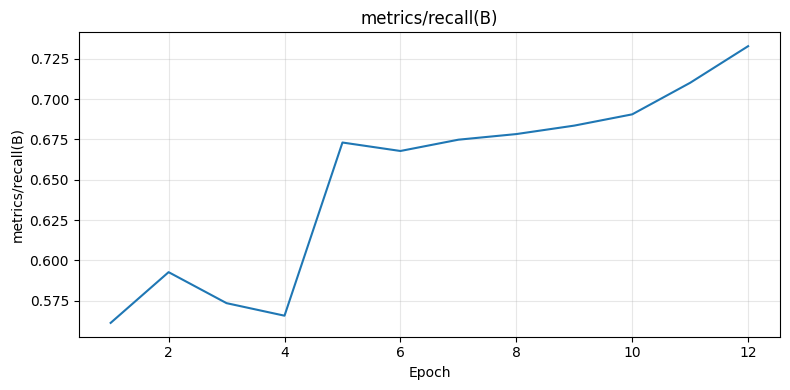

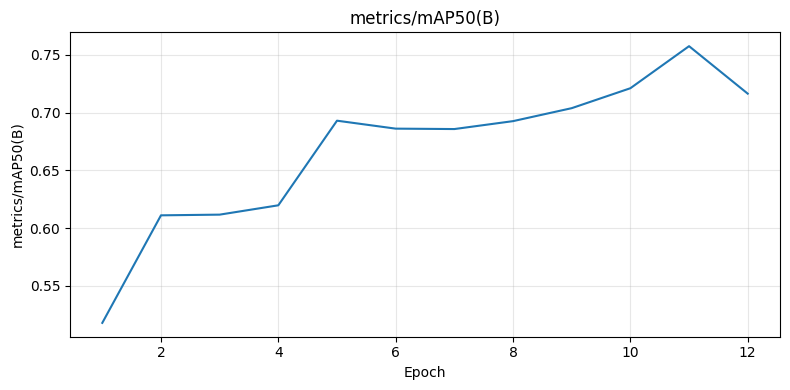

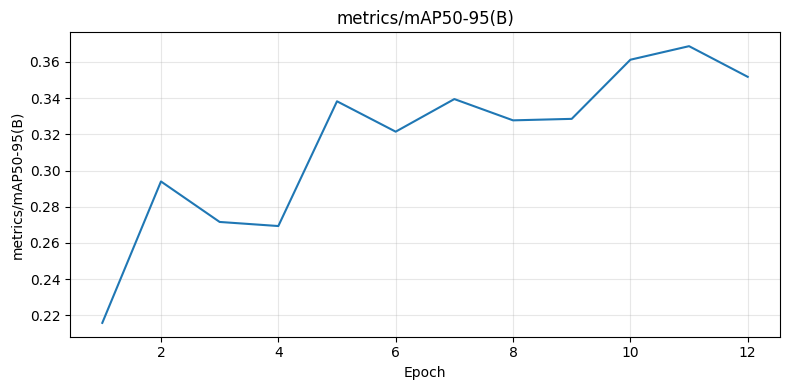

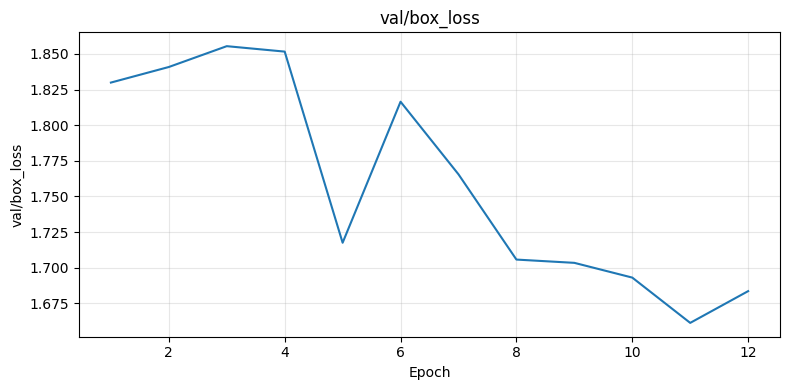

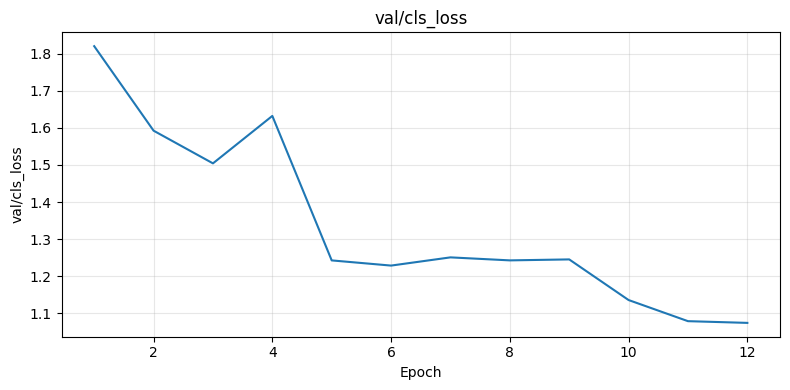

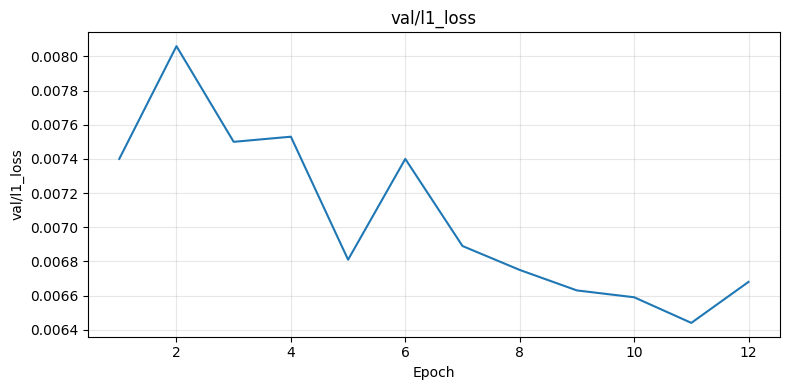

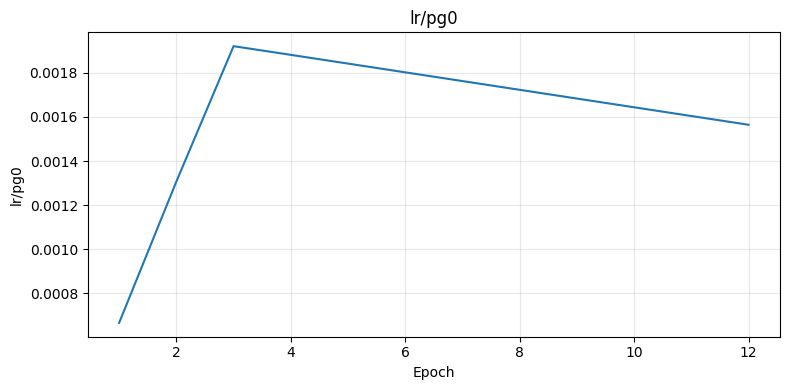

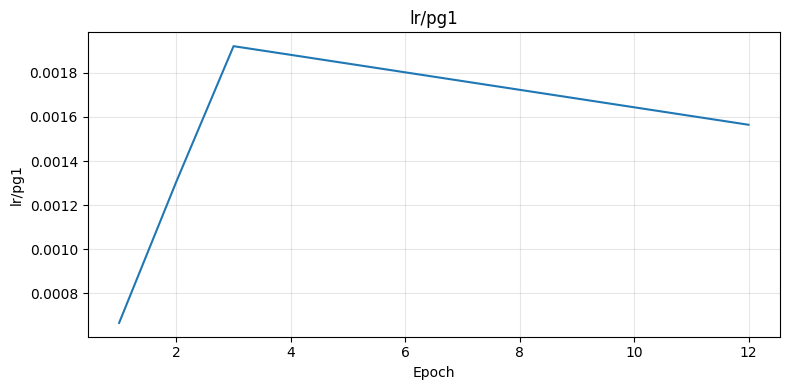

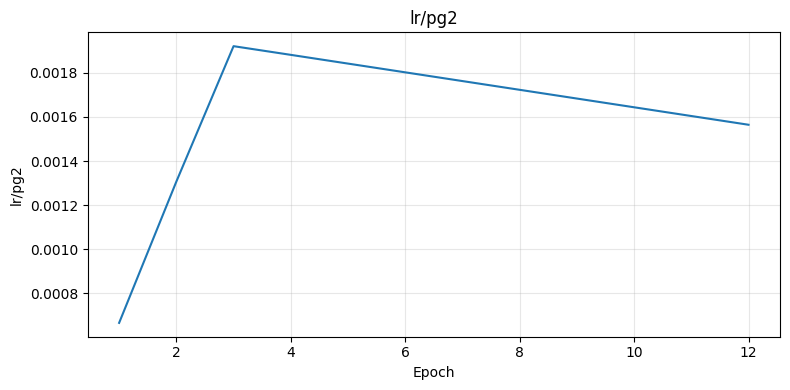

In [10]:
if RESULTS_CSV.exists():
    metric_columns = [
        c for c in results_df.columns
        if c != "epoch"
        and pd.api.types.is_numeric_dtype(results_df[c])
    ]

    for metric in metric_columns:
        plt.figure(figsize=(8, 4))
        plt.plot(results_df["epoch"], results_df[metric])
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(metric)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


In [12]:
from ultralytics import YOLO

In [19]:
IMG_SIZE = 640
BATCH_SIZE = 4
WORKERS = 2
DEVICE = "cpu"

In [20]:
best_model = YOLO(str(BEST_MODEL))

validation = best_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    plots=True
)

print("Precision :", validation.box.mp)
print("Recall    :", validation.box.mr)
print("mAP50     :", validation.box.map50)
print("mAP50-95  :", validation.box.map)


Ultralytics 8.4.152 🚀 Python-3.10.12 torch-2.14.0+cu130 CPU (13th Gen Intel Core i5-13420H)
YOLO26m summary (fused): 130 layers, 20,350,223 parameters, 0 gradients, 68.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 130.9±45.5 MB/s, size: 30.0 KB)
val: Scanning /home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/valid/labels.cache... 339 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 339/339 88.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 85/85 1.6s/it 2:151.7ss
                   all        339        572      0.775       0.71      0.758       0.37
Speed: 0.6ms preprocess, 389.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/detect/val
Precision : 0.7754677386358475
Recall    : 0.7097902097902098
mAP50     : 0.7576731644605728
mAP50-95  : 0.3695689246306932


In [21]:
try:
    precision = np.asarray(validation.box.p).reshape(-1)
    recall = np.asarray(validation.box.r).reshape(-1)
    ap50 = np.asarray(validation.box.ap50).reshape(-1)
    ap = np.asarray(validation.box.ap).reshape(-1)

    per_class = pd.DataFrame([{
        "class_id": 0,
        "class_name": "hotspot",
        "precision": float(precision[0]),
        "recall": float(recall[0]),
        "mAP50": float(ap50[0]),
        "mAP50-95": float(ap[0]),
    }])

    display(per_class)
except Exception as error:
    print("Could not extract per-class metrics:", error)


,class_id,class_name,precision,recall,mAP50,mAP50-95
0,0,hotspot,0.775468,0.70979,0.757673,0.369569


# Training Validation

In [26]:
import random
import cv2

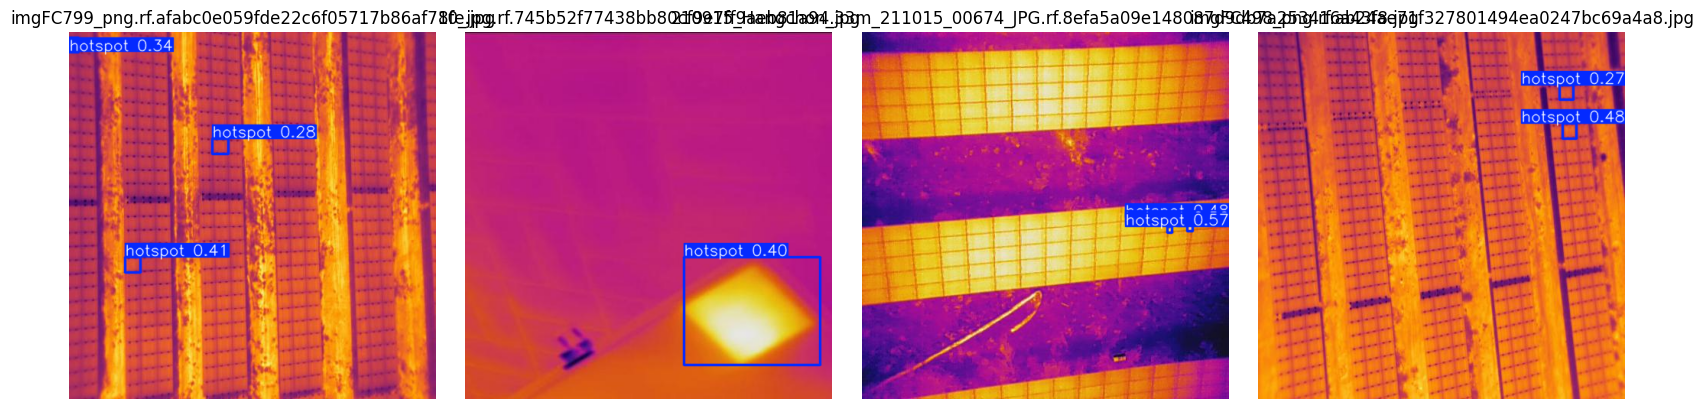

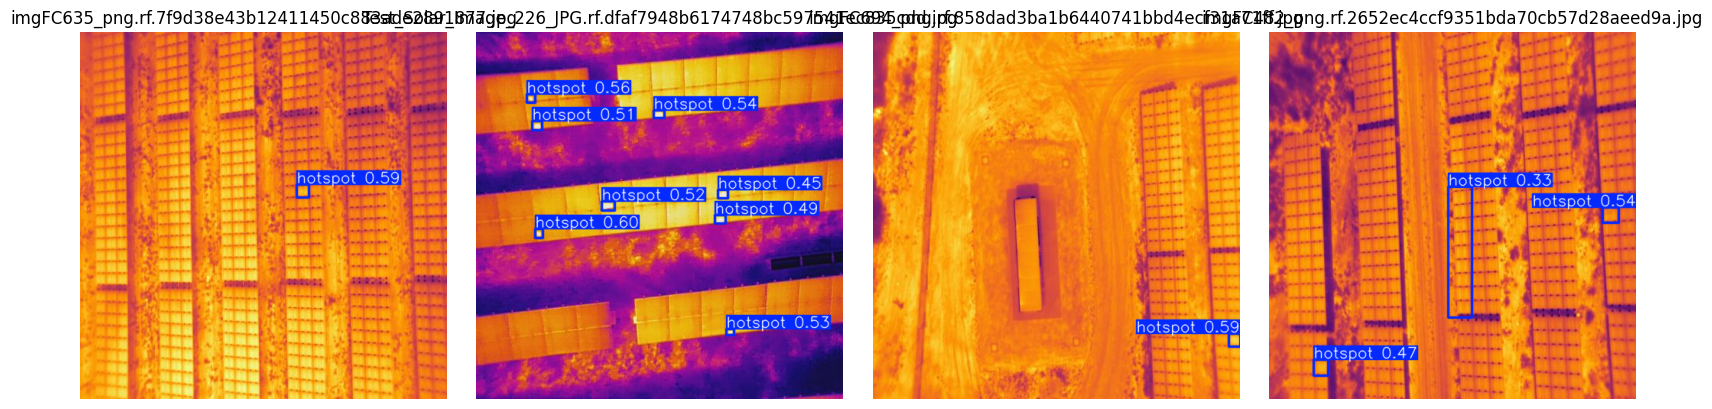

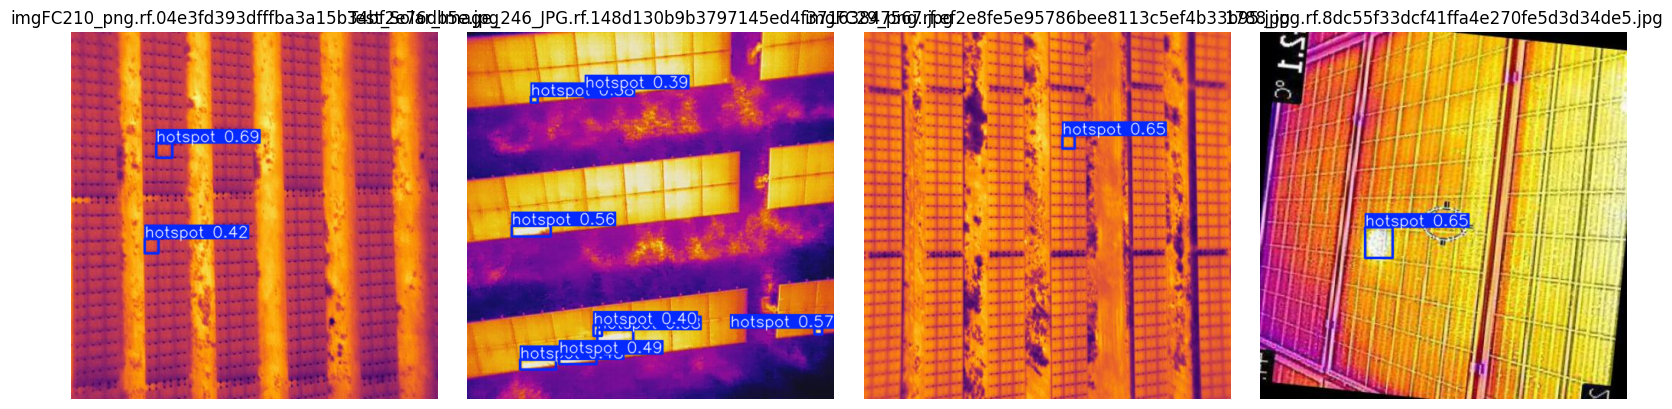

In [27]:
PREPARED_VALID_IMAGES = PREPARED_DATASET_DIR / "valid" / "images"

validation_images = [
    p for p in PREPARED_VALID_IMAGES.iterdir()
    if p.is_file()
]

random.seed(42)
sample_images = random.sample(
    validation_images,
    min(12, len(validation_images))
)

for start in range(0, len(sample_images), 4):
    batch_paths = sample_images[start:start + 4]

    predictions = best_model.predict(
        source=[str(p) for p in batch_paths],
        imgsz=IMG_SIZE,
        conf=0.25,
        device=DEVICE,
        verbose=False
    )

    fig, axes = plt.subplots(
        1,
        len(batch_paths),
        figsize=(16, 4)
    )

    if len(batch_paths) == 1:
        axes = [axes]

    for ax, prediction, path in zip(axes, predictions, batch_paths):
        plotted = prediction.plot()
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        ax.imshow(plotted)
        ax.set_title(path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [28]:
def collect_hotspot_sizes(image_dir, label_dir):
    records = []

    for image_path in image_dir.iterdir():
        if not image_path.is_file():
            continue

        label_path = label_dir / image_path.with_suffix(".txt").name
        if not label_path.exists():
            continue

        try:
            with Image.open(image_path) as image:
                width, height = image.size
        except Exception:
            continue

        for line in label_path.read_text().splitlines():
            values = line.strip().split()

            if len(values) != 5 or values[0] != "0":
                continue

            try:
                xc, yc, bw, bh = map(float, values[1:])

                records.append({
                    "image": image_path.name,
                    "width_px": bw * width,
                    "height_px": bh * height,
                    "area_px": bw * width * bh * height,
                    "normalized_area": bw * bh,
                    "normalized_width": bw,
                    "normalized_height": bh,
                })
            except Exception:
                pass

    return pd.DataFrame(records)

hotspot_size_df = collect_hotspot_sizes(
    PREPARED_DATASET_DIR / "valid" / "images",
    PREPARED_DATASET_DIR / "valid" / "labels"
)

if len(hotspot_size_df):
    q33 = hotspot_size_df["normalized_area"].quantile(0.33)
    q66 = hotspot_size_df["normalized_area"].quantile(0.66)

    def size_group(area):
        if area <= q33:
            return "small"
        if area <= q66:
            return "medium"
        return "large"

    hotspot_size_df["size_group"] = hotspot_size_df["normalized_area"].apply(size_group)

    display(
        hotspot_size_df["size_group"]
        .value_counts()
        .rename_axis("size_group")
        .reset_index(name="annotations")
    )

    plt.figure(figsize=(8, 5))
    plt.hist(hotspot_size_df["normalized_area"], bins=40)
    plt.xlabel("Normalized hotspot area")
    plt.ylabel("Annotations")
    plt.title("Hotspot Size Distribution")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No hotspot annotations found for size analysis.")


No hotspot annotations found for size analysis.


Error Analysis

In [29]:
VALID_LABELS_PREPARED = PREPARED_DATASET_DIR / "valid" / "labels"

fp_candidates = []
fn_candidates = []

for image_path in validation_images:
    prediction = best_model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=0.25,
        device=DEVICE,
        verbose=False
    )[0]

    prediction_count = (
        0 if prediction.boxes is None else len(prediction.boxes)
    )

    label_path = VALID_LABELS_PREPARED / image_path.with_suffix(".txt").name

    gt_count = 0
    if label_path.exists():
        gt_count = sum(
            1
            for line in label_path.read_text().splitlines()
            if line.strip().split()[:1] == ["0"]
        )

    if gt_count > 0 and prediction_count == 0:
        fn_candidates.append(image_path)

    if gt_count == 0 and prediction_count > 0:
        fp_candidates.append(image_path)

print("False-negative candidate images:", len(fn_candidates))
print("False-positive candidate images:", len(fp_candidates))


False-negative candidate images: 29
False-positive candidate images: 4


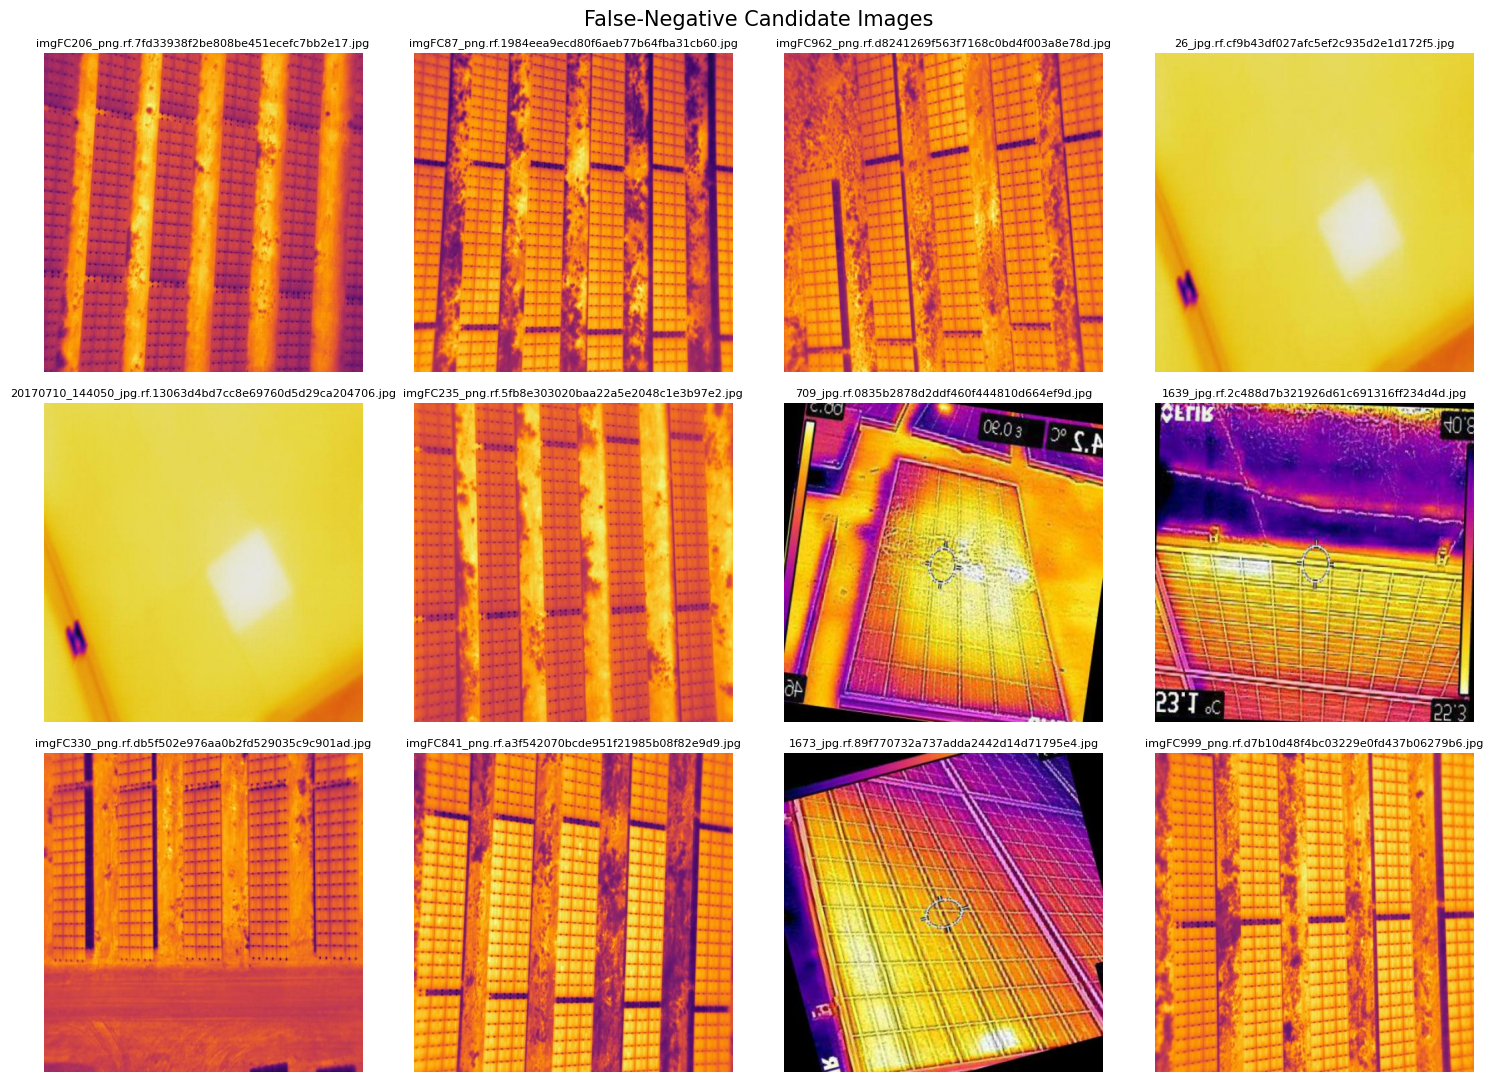

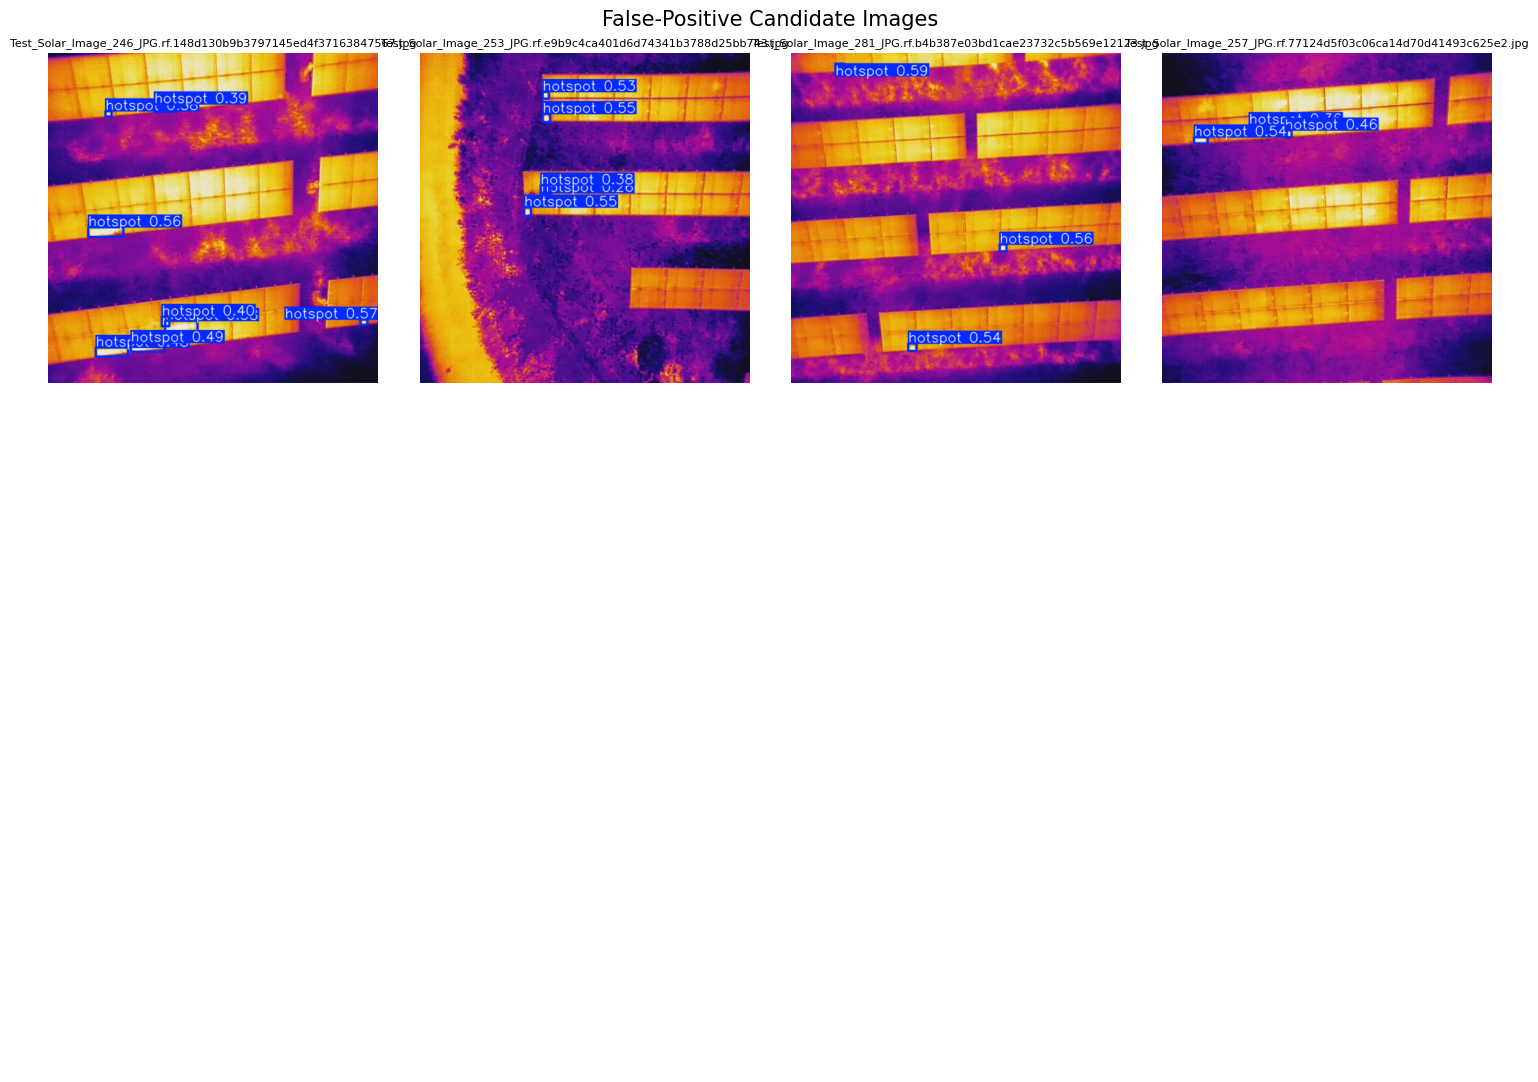

In [30]:
def show_error_cases(paths, title, limit=12):
    paths = paths[:limit]

    if not paths:
        print("No examples found.")
        return

    predictions = best_model.predict(
        source=[str(p) for p in paths],
        imgsz=IMG_SIZE,
        conf=0.25,
        device=DEVICE,
        verbose=False
    )

    fig, axes = plt.subplots(3, 4, figsize=(15, 11))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, prediction, path in zip(axes, predictions, paths):
        plotted = prediction.plot()
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        ax.imshow(plotted)
        ax.set_title(path.name, fontsize=8)
        ax.axis("off")

    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

show_error_cases(fn_candidates, "False-Negative Candidate Images")
show_error_cases(fp_candidates, "False-Positive Candidate Images")


,confidence,detections,images_with_detection
0,0.1,987,331
1,0.2,729,319
2,0.3,595,295
3,0.4,492,274
4,0.5,375,241
5,0.6,179,153
6,0.7,31,31
7,0.8,7,7
8,0.9,0,0


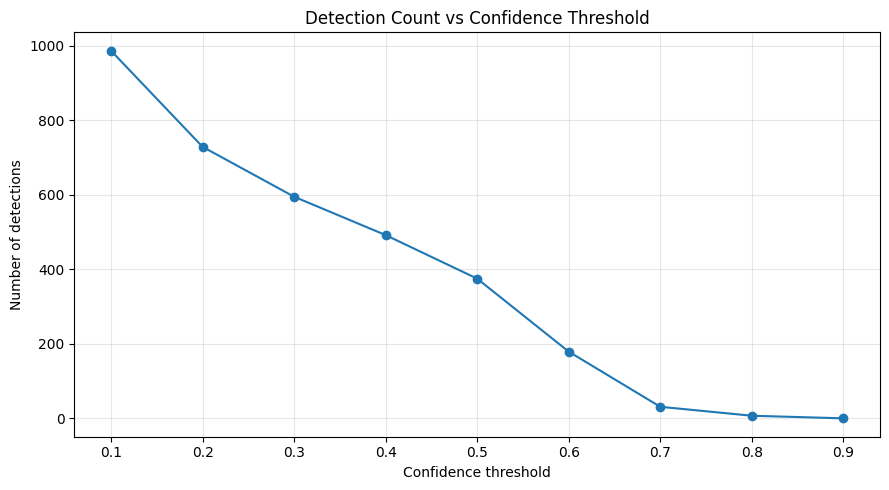

In [31]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_rows = []

for threshold in thresholds:
    detections = 0
    images_with_detection = 0

    for image_path in validation_images:
        prediction = best_model.predict(
            source=str(image_path),
            imgsz=IMG_SIZE,
            conf=threshold,
            device=DEVICE,
            verbose=False
        )[0]

        count = 0 if prediction.boxes is None else len(prediction.boxes)

        detections += count
        images_with_detection += int(count > 0)

    threshold_rows.append({
        "confidence": threshold,
        "detections": detections,
        "images_with_detection": images_with_detection,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

plt.figure(figsize=(9, 5))
plt.plot(
    threshold_df["confidence"],
    threshold_df["detections"],
    marker="o"
)
plt.xlabel("Confidence threshold")
plt.ylabel("Number of detections")
plt.title("Detection Count vs Confidence Threshold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Test Evaluation

In [32]:
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    plots=True
)

FINAL_PRECISION = float(test_results.box.mp)
FINAL_RECALL = float(test_results.box.mr)
FINAL_MAP50 = float(test_results.box.map50)
FINAL_MAP5095 = float(test_results.box.map)

print("FINAL TEST METRICS")
print("------------------")
print("Precision :", FINAL_PRECISION)
print("Recall    :", FINAL_RECALL)
print("mAP50     :", FINAL_MAP50)
print("mAP50-95  :", FINAL_MAP5095)


Ultralytics 8.4.152 🚀 Python-3.10.12 torch-2.14.0+cu130 CPU (13th Gen Intel Core i5-13420H)
YOLO26m summary (fused): 130 layers, 20,350,223 parameters, 0 gradients, 68.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 142.2±63.2 MB/s, size: 37.0 KB)
val: Scanning /home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/test/labels... 235 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 235/235 1.9Kit/s 0.1s<0.1s
val: New cache created: /home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 1.5s/it 1:301.6sss
                   all        235        489       0.78      0.703      0.732      0.323
Speed: 0.6ms preprocess, 376.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/detect/val-2
FINAL TEST METRICS
--

In [33]:
UNSEEN_DIR = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Database/thermal_unseen_test"
)

if UNSEEN_DIR.exists():
    unseen_images = [
        p for p in UNSEEN_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in {
            ".jpg", ".jpeg", ".png", ".bmp",
            ".tif", ".tiff", ".webp"
        }
    ]

    print("Unseen images:", len(unseen_images))

    for image_path in unseen_images[:12]:
        prediction = best_model.predict(
            source=str(image_path),
            imgsz=IMG_SIZE,
            conf=0.25,
            device=DEVICE,
            verbose=False
        )[0]

        plotted = prediction.plot()
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(7, 7))
        plt.imshow(plotted)
        plt.title(image_path.name)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("Unseen-data directory not present:", UNSEEN_DIR)


Unseen-data directory not present: /home/hraj/Workspace/Solor_defect_DB/Database/thermal_unseen_test


# Model Deployment

In [35]:
import shutil

In [38]:
FINAL_MODEL_DIR = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline"
)

FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_PT = FINAL_MODEL_DIR / "best.pt"

shutil.copy2(BEST_MODEL, FINAL_PT)

print("PyTorch model saved:")
print(FINAL_PT)


PyTorch model saved:
/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/best.pt


In [39]:
exported_onnx = best_model.export(
    format="onnx",
    imgsz=IMG_SIZE,
    dynamic=False,
    simplify=True
)

exported_onnx = Path(str(exported_onnx))
FINAL_ONNX = FINAL_MODEL_DIR / "best.onnx"

if exported_onnx.resolve() != FINAL_ONNX.resolve():
    shutil.copy2(exported_onnx, FINAL_ONNX)

print("ONNX model saved:")
print(FINAL_ONNX)


Ultralytics 8.4.152 🚀 Python-3.10.12 torch-2.14.0+cu130 CPU (13th Gen Intel Core i5-13420H)
YOLO26m summary (fused): 130 layers, 20,350,223 parameters, 0 gradients, 68.1 GFLOPs

PyTorch: starting from '/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (166.9 MB)

ONNX: starting export with onnx 1.22.0 opset 18...


/home/hraj/.local/lib/python3.10/site-packages/ultralytics/nn/modules/head.py:211: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.dynamic or self.shape != shape:


ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.8s, saved as '/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx' (77.9 MB)

Export complete (3.1s)
Results saved to /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx
Predict:         yolo predict task=detect model=/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx imgsz=640 data=/home/hraj/Workspace/Solor_defect_DB/Database/thermal_hotspot_detection_dataset/data.yaml  
Visualize:       https://netron.app
ONNX model saved:
/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/best.onnx